Dataset Shape: (8760, 8)
     Date-Hour(NMT)  WindSpeed  Sunshine  AirPressure  Radiation  \
0  01.01.2017-00:00        0.6         0       1003.8       -7.4   
1  01.01.2017-01:00        1.7         0       1003.5       -7.4   
2  01.01.2017-02:00        0.6         0       1003.4       -6.7   
3  01.01.2017-03:00        2.4         0       1003.3       -7.2   
4  01.01.2017-04:00        4.0         0       1003.1       -6.3   

   AirTemperature  RelativeAirHumidity  SystemProduction  
0             0.1                   97               0.0  
1            -0.2                   98               0.0  
2            -1.2                   99               0.0  
3            -1.3                   99               0.0  
4             3.6                   67               0.0  


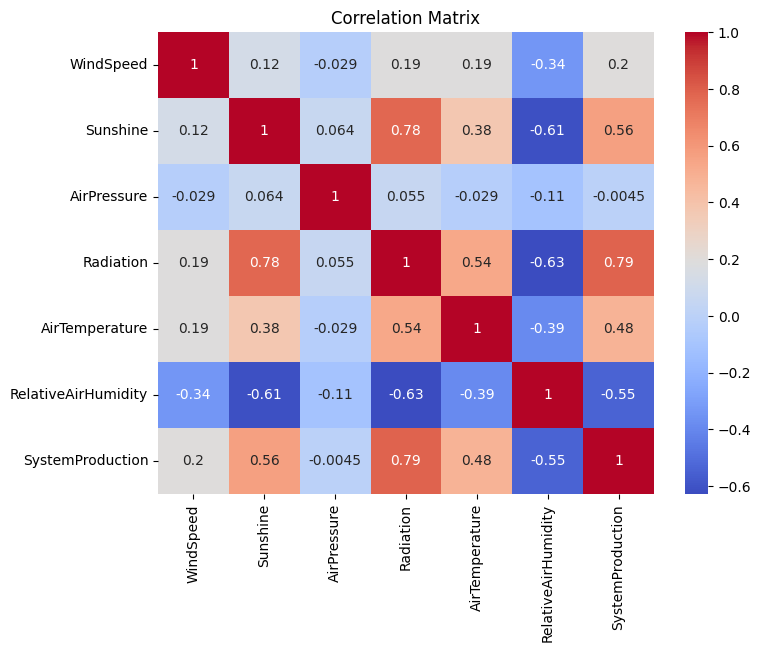

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Forecast Horizon: 1 Day(s)
Linear Regression RMSE: 282.167 R2: 0.175
Polynomial Regression RMSE: 259.097 R2: 0.304
Random Forest RMSE: 267.714 R2: 0.257
ANN RMSE: 255.277 R2: 0.324

Forecast Horizon: 3 Day(s)
Linear Regression RMSE: 282.297 R2: 0.175
Polynomial Regression RMSE: 259.243 R2: 0.304
Random Forest RMSE: 267.867 R2: 0.257
ANN RMSE: 255.423 R2: 0.324

Forecast Horizon: 5 Day(s)
Linear Regression RMSE: 282.432 R2: 0.175
Polynomial Regression RMSE: 259.391 R2: 0.304
Random Forest RMSE: 268.021 R2: 0.257
ANN RMSE: 255.567 R2: 0.324

Forecast Horizon: 10 Day(s)
Linear Regression RMSE: 282.808 R2: 0.175
Polynomial Regression RMSE: 259.735 R2: 0.304
Random Forest RMSE: 268.404 R2: 0.257
ANN RMSE: 255.91 R2: 0.324

Final Results Table
                    Model  Forecast Horizon        RMSE        R2
0       Linear Regression                 1  282.167407  0.174561
1   Polynomial Regression                 1  259.096995  0.304022
2           Random Forest                 1  267.7143

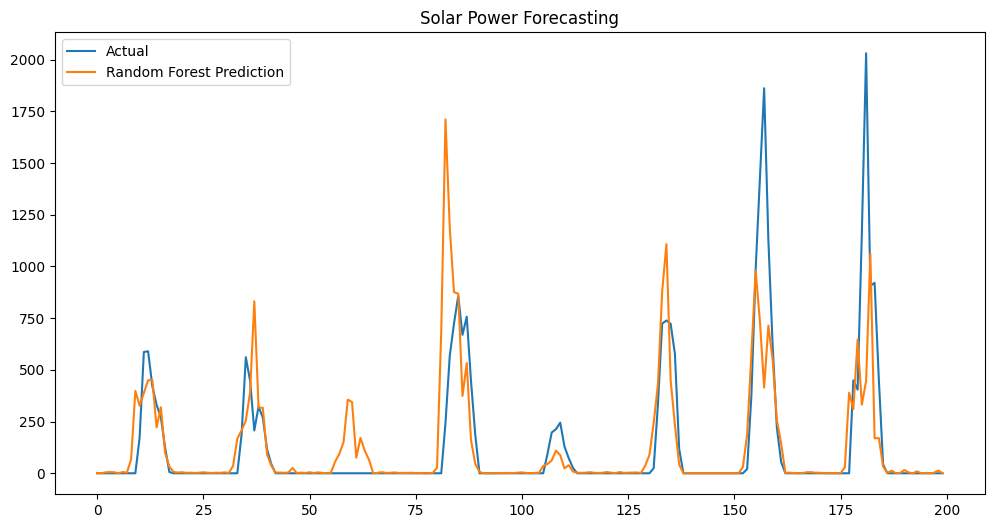

In [ ]:
# =========================================
# Solar Power Forecasting Research Pipeline
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =========================================
# 1. Load Dataset
# =========================================

url = "https://raw.githubusercontent.com/rayhaneeeruet/Solar-Data/refs/heads/main/Solar%20Power%20Plant%20Data.csv"

data = pd.read_csv(url)

print("Dataset Shape:", data.shape)
print(data.head())

# =========================================
# 2. Feature Selection
# =========================================

features = [
    "Radiation",
    "AirTemperature",
    "WindSpeed",
    "RelativeAirHumidity"
]

target = "SystemProduction"

X = data[features]
y = data[target]

# =========================================
# 3. Correlation Matrix (paper step)
# =========================================

# Drop the 'Date-Hour(NMT)' column as it's not numeric and causes issues with correlation calculation
data_numeric = data.drop(columns=['Date-Hour(NMT)'], errors='ignore')

plt.figure(figsize=(8,6))
sns.heatmap(data_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# =========================================
# 4. Normalize Data
# =========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# 5. Train/Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

# =========================================
# 6. Models
# =========================================

models = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
models["Linear Regression"] = lr

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
models["Polynomial Regression"] = pr

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42
)
rf.fit(X_train, y_train)
models["Random Forest"] = rf

# ANN
ann = Sequential()

ann.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))
ann.add(Dense(32, activation="relu"))
ann.add(Dense(1))

ann.compile(optimizer="adam", loss="mse")

ann.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=0
)

models["ANN"] = ann

# =========================================
# 7. Multi-Step Forecast Function
# =========================================

def forecast_steps(model, X_test, steps, model_type="sklearn"):

    preds = []

    for i in range(len(X_test) - steps):

        if model_type == "poly":

            pred = model.predict(poly.transform([X_test[i]]))[0]

        elif model_type == "ann":

            pred = model.predict(np.array([X_test[i]]), verbose=0)[0][0]

        else:

            pred = model.predict([X_test[i]])[0]

        preds.append(pred)

    return np.array(preds)

# =========================================
# 8. Evaluate for each horizon
# =========================================

horizons = [1,3,5,10]

results = []

for horizon in horizons:

    print("\nForecast Horizon:", horizon, "Day(s)")

    for name, model in models.items():

        if name == "Polynomial Regression":

            preds = forecast_steps(model, X_test, horizon, "poly")

        elif name == "ANN":

            preds = forecast_steps(model, X_test, horizon, "ann")

        else:

            preds = forecast_steps(model, X_test, horizon)

        y_true = y_test.values[:len(preds)]

        rmse = np.sqrt(mean_squared_error(y_true, preds))
        r2 = r2_score(y_true, preds)

        results.append([name, horizon, rmse, r2])

        print(name, "RMSE:", round(rmse,3), "R2:", round(r2,3))

# =========================================
# 9. Result Table
# =========================================

results_df = pd.DataFrame(
    results,
    columns=["Model","Forecast Horizon","RMSE","R2"]
)

print("\nFinal Results Table")
print(results_df)

# =========================================
# 10. Plot Example Forecast
# =========================================

rf_preds = rf.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(rf_preds[:200], label="Random Forest Prediction")

plt.title("Solar Power Forecasting")
plt.legend()
plt.show()

In [ ]:
def forecast_horizon(model, X_test, horizon):

    preds = []

    for i in range(len(X_test)-horizon):

        pred = model.predict([X_test[i]])[0]

        preds.append(pred)

    return np.array(preds)

In [ ]:
rf_1 = forecast_horizon(rf, X_test, 1)
rf_3 = forecast_horizon(rf, X_test, 3)
rf_5 = forecast_horizon(rf, X_test, 5)
rf_10 = forecast_horizon(rf, X_test, 10)

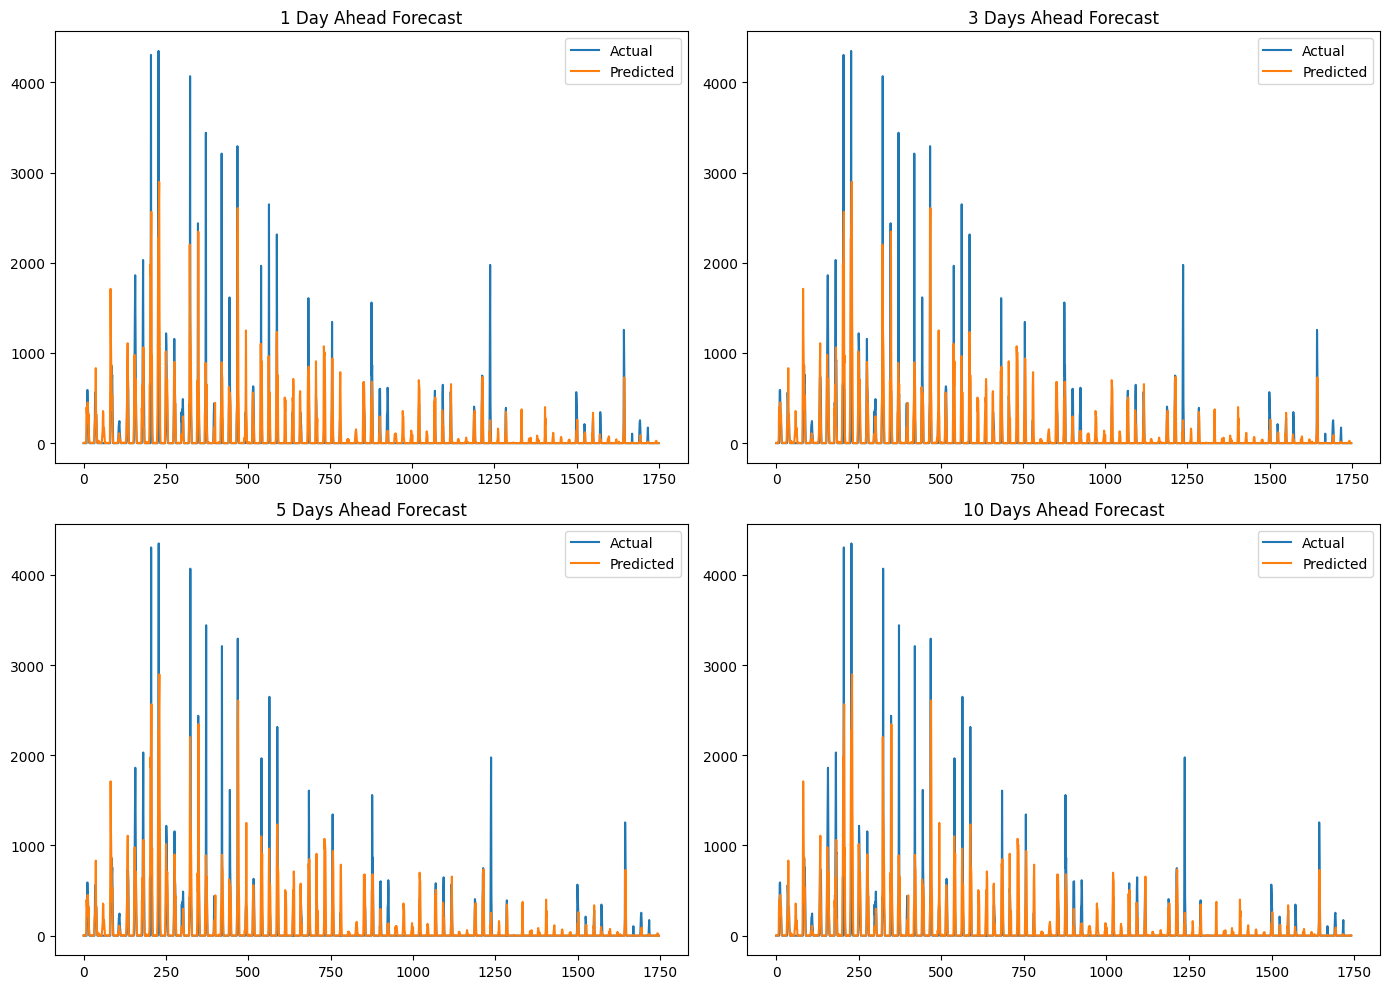

In [ ]:
plt.figure(figsize=(14,10))

# 1 Day
plt.subplot(2,2,1)
plt.plot(y_test.values[:len(rf_1)], label="Actual")
plt.plot(rf_1, label="Predicted")
plt.title("1 Day Ahead Forecast")
plt.legend()

# 3 Days
plt.subplot(2,2,2)
plt.plot(y_test.values[:len(rf_3)], label="Actual")
plt.plot(rf_3, label="Predicted")
plt.title("3 Days Ahead Forecast")
plt.legend()

# 5 Days
plt.subplot(2,2,3)
plt.plot(y_test.values[:len(rf_5)], label="Actual")
plt.plot(rf_5, label="Predicted")
plt.title("5 Days Ahead Forecast")
plt.legend()

# 10 Days
plt.subplot(2,2,4)
plt.plot(y_test.values[:len(rf_10)], label="Actual")
plt.plot(rf_10, label="Predicted")
plt.title("10 Days Ahead Forecast")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.style.use("seaborn-v0_8")

In [ ]:
sns.set_style("whitegrid")

In [ ]:
results = {
    "Linear Regression": {},
    "Polynomial Regression": {},
    "ANN": {},
    "Random Forest": {}
}

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Get predictions for each model for a single step (equivalent to horizon 1 in the original evaluation)

# Linear Regression
pred_lr = models["Linear Regression"].predict(X_test)

# Polynomial Regression
# Need to transform X_test using the pre-fitted PolynomialFeatures 'poly'
pred_pr = models["Polynomial Regression"].predict(X_test_poly)

# ANN
# ANN predict returns a 2D array, flatten it for metric calculation
pred_ann = models["ANN"].predict(X_test, verbose=0).flatten()

# Random Forest
pred_rf = models["Random Forest"].predict(X_test)

# For consistency with the original evaluation (using forecast_steps for horizon=1),
# y_test needs to be sliced to match the length of predictions (len(X_test) - horizon)
# For horizon=1, the length will be len(X_test) - 1
y_test_sliced = y_test.values[:len(X_test) - 1]

# Calculate metrics for each model, slicing predictions to match y_test_sliced

# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test_sliced, pred_lr[:len(y_test_sliced)]))
r2_lr = r2_score(y_test_sliced, pred_lr[:len(y_test_sliced)])

# Polynomial Regression
rmse_pr = np.sqrt(mean_squared_error(y_test_sliced, pred_pr[:len(y_test_sliced)]))
r2_pr = r2_score(y_test_sliced, pred_pr[:len(y_test_sliced)])

# ANN
rmse_ann = np.sqrt(mean_squared_error(y_test_sliced, pred_ann[:len(y_test_sliced)]))
r2_ann = r2_score(y_test_sliced, pred_ann[:len(y_test_sliced)])

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test_sliced, pred_rf[:len(y_test_sliced)]))
r2_rf = r2_score(y_test_sliced, pred_rf[:len(y_test_sliced)])

# Store results in the 'results' dictionary
results["Linear Regression"] = [rmse_lr, r2_lr]
results["Polynomial Regression"] = [rmse_pr, r2_pr]
results["ANN"] = [rmse_ann, r2_ann]
results["Random Forest"] = [rmse_rf, r2_rf]

print("Metrics (Single-step prediction aligned with Horizon 1 from original evaluation):")
for model_name, metrics in results.items():
    print(f"{model_name}: RMSE={metrics[0]:.3f}, R2={metrics[1]:.3f}")

Metrics (Single-step prediction aligned with Horizon 1 from original evaluation):
Linear Regression: RMSE=282.167, R2=0.175
Polynomial Regression: RMSE=259.097, R2=0.304
ANN: RMSE=255.277, R2=0.324
Random Forest: RMSE=267.714, R2=0.257


In [ ]:
models = list(results.keys())

rmse_values = [results[m][0] for m in models]
r2_values = [results[m][1] for m in models]

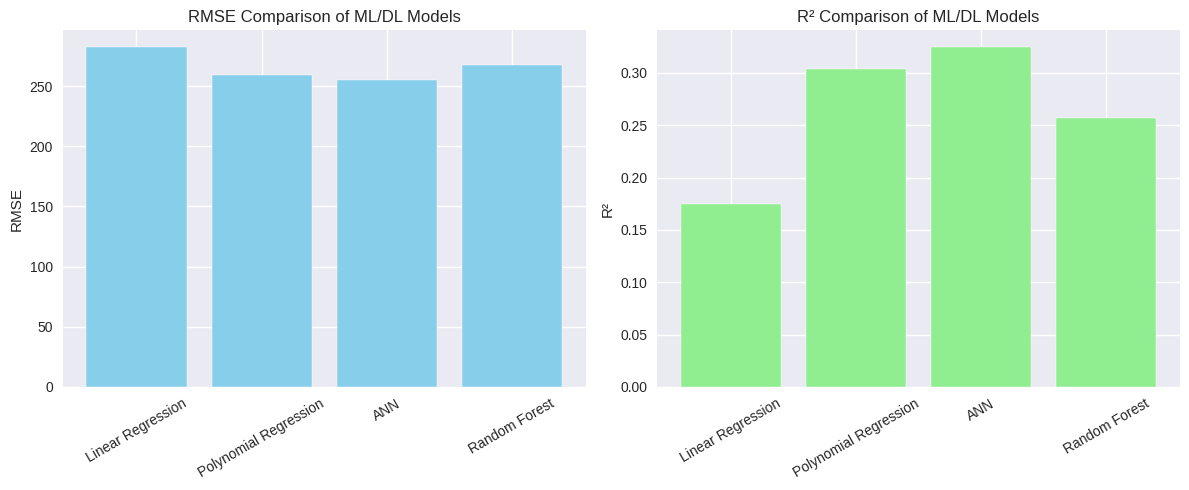

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# RMSE Plot
plt.subplot(1,2,1)
plt.bar(models, rmse_values, color='skyblue')
plt.title("RMSE Comparison of ML/DL Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)

# R2 Plot
plt.subplot(1,2,2)
plt.bar(models, r2_values, color='lightgreen')
plt.title("R² Comparison of ML/DL Models")
plt.ylabel("R²")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Forecast horizons
horizons = [1,3,5,10]

# Store results
table_results = []

models = {
    "LR": lr,
    "PR": pr,
    "ANN": ann,
    "RFR": rf
}

for name, model in models.items():

    rmse_list = []

    for h in horizons:

        preds = []

        for i in range(len(X_test)-h):

            if name == "PR":
                pred = model.predict(poly.transform([X_test[i]]))[0]

            elif name == "ANN":
                pred = model.predict(np.array([X_test[i]]), verbose=0)[0][0]

            else:
                pred = model.predict([X_test[i]])[0]

            preds.append(pred)

        y_true = y_test.values[:len(preds)]

        rmse = np.sqrt(mean_squared_error(y_true, preds))

        rmse_list.append(round(rmse,3))

    table_results.append([name] + rmse_list)

# Create DataFrame

table = pd.DataFrame(
    table_results,
    columns=["Model","Next 1 Day","Next 3 Days","Next 5 Days","Next 10 Days"]
)

print("\nTable 1: RMSE Comparison Among Models\n")
print(table)


Table 1: RMSE Comparison Among Models

  Model  Next 1 Day  Next 3 Days  Next 5 Days  Next 10 Days
0    LR     282.167      282.297      282.432       282.808
1    PR     259.097      259.243      259.391       259.735
2   ANN     255.277      255.423      255.567       255.910
3   RFR     267.714      267.867      268.021       268.404
